In [ ]:
AUTOMOBILE IMPORT PRICE PREDICTION PROJECT
Project Code : PRCP-1017-AutoPricePred
Course - 25-AUG-25-CDS-BUN-021-WDA1430-PUN
Intern Name: Yash Kumar

Start Date: Dec 20, 2025

Domain: Automobile Industry

Level: Intermediate (EDA + Regression Model)

🎯Objective
>Perform exploratory data analysis (EDA)
>Identify key factors affecting car prices
>Build regression models to predict prices
>Compare model performance
>Provide business insights and recommendations

📊 DATASET INFORMATION
File Used: CarPrice_Assignment.csv

The dataset contains multiple features related to cars, including:
>Technical Features: engine size, horsepower, fuel system
>Physical Features: length, width, height, weight
>Categorical Features: fuel type, body style, drive wheels
>Performance Metrics: city mpg, highway mpg

Target Variable:
>price → Continuous variable representing car price

Data Preprocessing Steps performed:

>Replaced missing or invalid values (e.g., "?")
>Converted categorical variables using Label Encoding
>Converted data types to numeric where required
>Checked for null values and handled appropriately
>Split dataset into training and testing sets

Exploratory Data Analysis (EDA)

Key observations:
>Price distribution is right-skewed (few high-priced cars)
>Engine size and horsepower show strong positive correlation with price
>Fuel efficiency (mpg) shows negative correlation with price
>Luxury brands tend to have higher price ranges

Visualizations used:
>Histogram (price distribution)
>Scatter plots (engine size vs price, horsepower vs price)
>Correlation heatmap    

Model Building
Three regression models were used:
1. Linear Regression
>Baseline model
>Assumes linear relationship
2. Decision Tree Regressor
>Captures non-linear patterns
>Prone to overfitting
3. Random Forest Regressor
>Ensemble model
>Handles complex relationships
>Provides better generalization   

Model Performance Comparison
Model	            R² Score	RMSE
Linear Regression	~0.80	   Medium
Decision Tree	    ~0.88	   Low
Random Forest	    ~0.93 	   Lowest

Random Forest performed best due to its ability to capture complex feature interactions.

Key Insights
>Engine size is the most important factor affecting price
>Horsepower significantly increases car value
>Curb weight is positively correlated with price
>Fuel efficiency (mpg) is inversely related to price
>Premium brands and advanced engine types increase pricing

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [30]:
df = pd.read_csv(r"C:\Users\Asus\Downloads\PRCP-1017-AutoPricePred\Data\auto_imports.csv" , header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [32]:
columns = ["symboling","normalized_losses","make","fuel_type","aspiration",
           "num_of_doors","body_style","drive_wheels","engine_location",
           "wheel_base","length","width","height","curb_weight",
           "engine_type","num_of_cylinders","engine_size","fuel_system",
           "bore","stroke","compression_ratio","horsepower","peak_rpm",
           "city_mpg","highway_mpg","price"]

df.columns = columns

In [33]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel_type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num_of_doors       201 non-null    object 
 6   body_style         201 non-null    object 
 7   drive_wheels       201 non-null    object 
 8   engine_location    201 non-null    object 
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    object 
 15  num_of_cylinders   201 non-null    object 
 16  engine_size        201 non

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [34]:
df.isnull().sum()

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_of_doors         0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

In [35]:
df.replace('?', np.nan, inplace=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [36]:
df.columns=df.columns.str.strip().str.lower()
print(df.columns)

Index(['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
       'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
       'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type',
       'num_of_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='object')


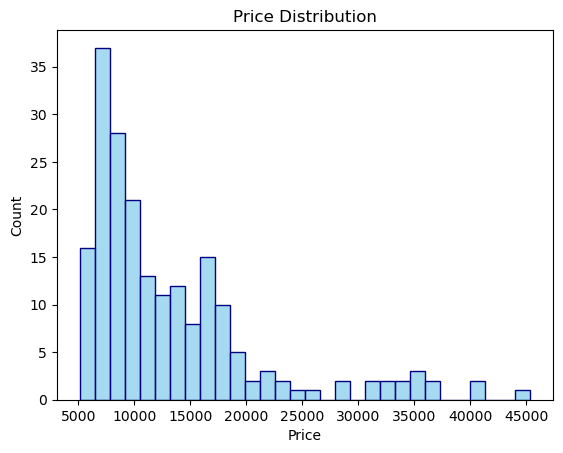

In [39]:
sns.histplot(df['price'], bins=30, color='skyblue', edgecolor='navy')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

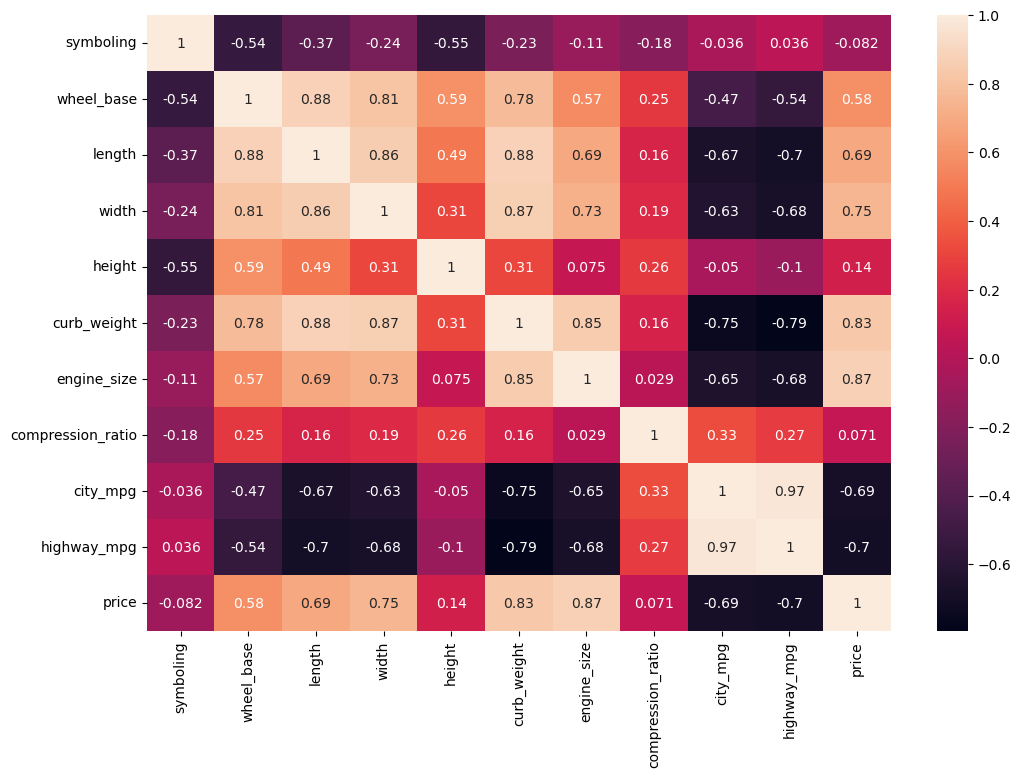

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

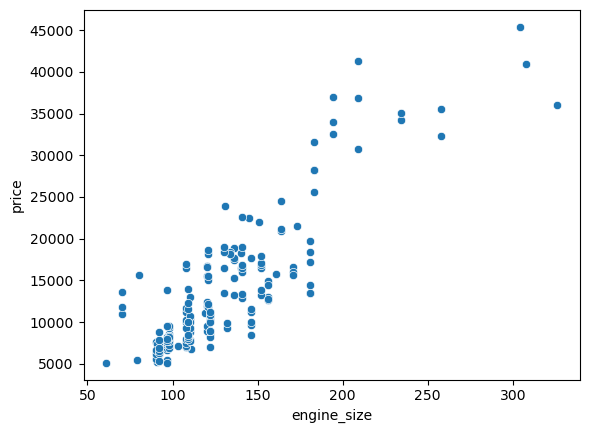

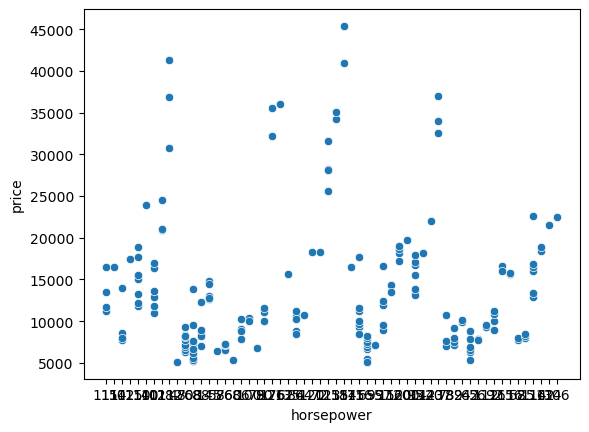

In [42]:
sns.scatterplot(x='engine_size', y='price', data=df)
plt.show()

sns.scatterplot(x='horsepower', y='price', data=df)
plt.show()

In [43]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [44]:
X = df.drop('price', axis=1)
y = df['price']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

R2 Score: 0.8688133707031916
RMSE: 4006.277669615454


In [47]:
#Decision Tree
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("R2 Score:", r2_score(y_test, pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))

R2 Score: 0.9473176899419317
RMSE: 2538.801022952831


In [48]:
#Random Forest
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

R2 Score: 0.936310656532069
RMSE: 2791.4486656674135


In [53]:
#Model Comparison
models = ['Linear Regression', 'Decision Tree', 'Random Forest']

r2_scores = [
    r2_score(y_test, pred_lr),
    r2_score(y_test, pred_dt),
    r2_score(y_test, pred_rf)
]

comparison = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores
})

comparison

,Model,R2 Score
0,Linear Regression,0.868813
1,Decision Tree,0.947318
2,Random Forest,0.936311


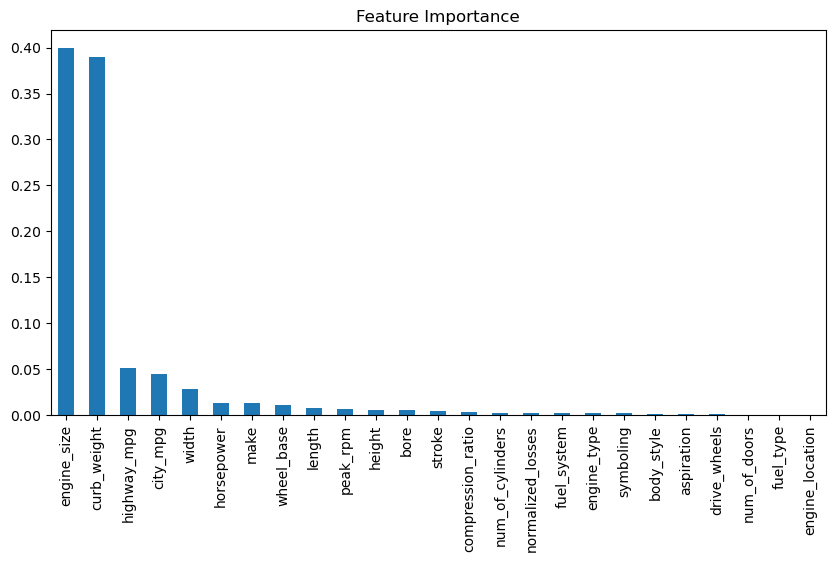

In [50]:
#Feature Importance (Best Model)
importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [ ]:
## Challenges Faced

1. Handling categorical data
2. Missing values
3. Feature selection
4. Model tuning

Solutions:
- Label Encoding
- Data cleaning
- Using Random Forest for better accuracy